# Basic Charts

This notebook answers first-level questions from `studentInfo.csv`, especially around modules/courses and student counts.

Important grain note: `studentInfo.csv` has one row per student-module-presentation attempt. A student can appear more than once if they take more than one module or presentation.

## Current answers from the raw data

- Total student-module-presentation rows: **32,593**
- Unique students: **28,785**
- Students taking more than one module: **2,479**
- Students taking exactly one module: **26,306**
- Students taking exactly two modules: **2,459**
- Students taking exactly three modules: **20**

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path('../data/raw').resolve()
student_info = pd.read_csv(RAW_DIR / 'studentInfo.csv')

student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [3]:
total_rows = len(student_info)
unique_students = student_info['id_student'].nunique()
modules = sorted(student_info['code_module'].unique())

summary = pd.DataFrame({
    'metric': ['student_module_presentation_rows', 'unique_students', 'number_of_modules'],
    'value': [total_rows, unique_students, len(modules)]
})

summary

,metric,value
0,student_module_presentation_rows,32593
1,unique_students,28785
2,number_of_modules,7


## How many students are in each module?

This uses unique students per module. It is different from counting rows because a student may appear in more than one presentation of the same module.

In [4]:
students_by_module = (
    student_info
    .groupby('code_module')['id_student']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='unique_students')
)

students_by_module

,code_module,unique_students
0,BBB,7692
1,FFF,7397
2,DDD,5848
3,CCC,4251
4,EEE,2859
5,GGG,2525
6,AAA,712


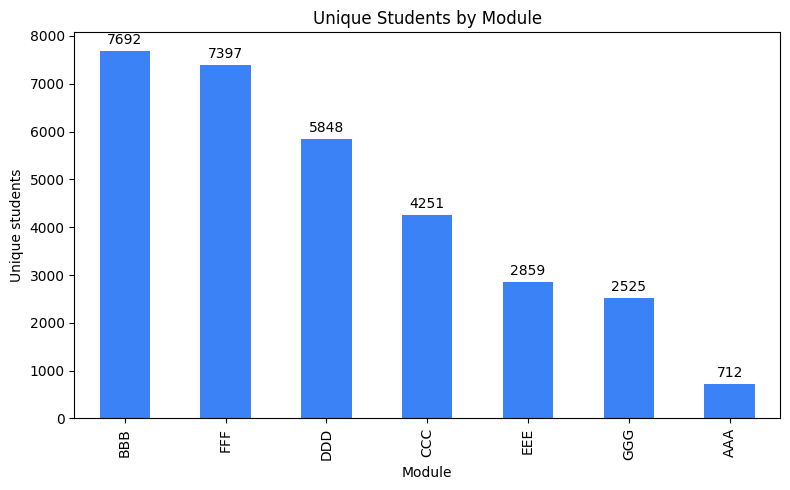

In [5]:
ax = students_by_module.plot(
    kind='bar',
    x='code_module',
    y='unique_students',
    legend=False,
    figsize=(8, 5),
    color='#3b82f6'
)

ax.set_title('Unique Students by Module')
ax.set_xlabel('Module')
ax.set_ylabel('Unique students')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

## How many rows/attempts are in each module?

This counts student-module-presentation rows. Use this when the analysis is about attempts or presentations rather than unique people.

In [6]:
attempts_by_module = (
    student_info['code_module']
    .value_counts()
    .rename_axis('code_module')
    .reset_index(name='student_module_presentation_rows')
)

attempts_by_module

,code_module,student_module_presentation_rows
0,BBB,7909
1,FFF,7762
2,DDD,6272
3,CCC,4434
4,EEE,2934
5,GGG,2534
6,AAA,748


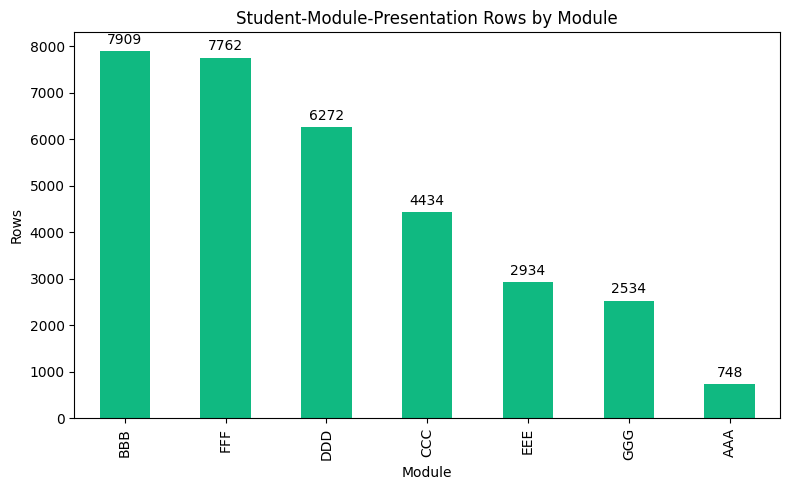

In [7]:
ax = attempts_by_module.plot(
    kind='bar',
    x='code_module',
    y='student_module_presentation_rows',
    legend=False,
    figsize=(8, 5),
    color='#10b981'
)

ax.set_title('Student-Module-Presentation Rows by Module')
ax.set_xlabel('Module')
ax.set_ylabel('Rows')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

## How many students take more than one module?

In [8]:
modules_per_student = (
    student_info
    .groupby('id_student')['code_module']
    .nunique()
    .reset_index(name='number_of_modules')
)

students_more_than_one_module = (modules_per_student['number_of_modules'] > 1).sum()
students_more_than_one_module

2479

In [9]:
students_by_module_count = (
    modules_per_student['number_of_modules']
    .value_counts()
    .sort_index()
    .rename_axis('number_of_modules')
    .reset_index(name='students')
)

students_by_module_count

,number_of_modules,students
0,1,26306
1,2,2459
2,3,20


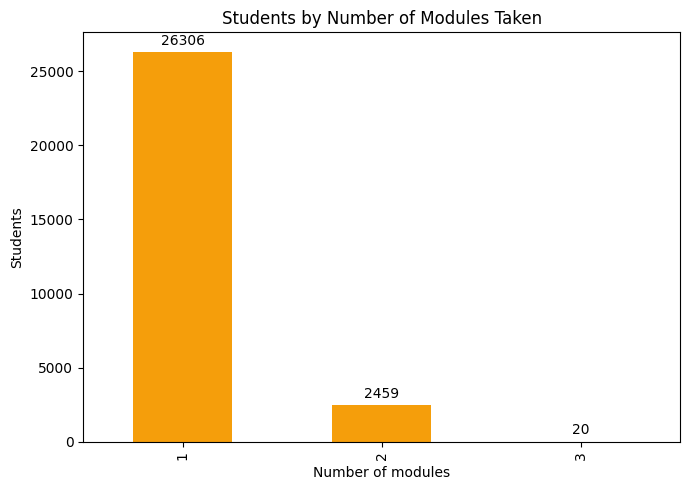

In [10]:
ax = students_by_module_count.plot(
    kind='bar',
    x='number_of_modules',
    y='students',
    legend=False,
    figsize=(7, 5),
    color='#f59e0b'
)

ax.set_title('Students by Number of Modules Taken')
ax.set_xlabel('Number of modules')
ax.set_ylabel('Students')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

## Optional: modules by final result

This chart helps connect module enrollment to outcomes.

In [11]:
result_by_module = pd.crosstab(
    student_info['code_module'],
    student_info['final_result']
)

result_by_module

final_result,Distinction,Fail,Pass,Withdrawn
code_module,,,,
AAA,44,91,487,126
BBB,677,1767,3077,2388
CCC,498,781,1180,1975
DDD,383,1412,2227,2250
EEE,356,562,1294,722
FFF,670,1711,2978,2403
GGG,396,728,1118,292


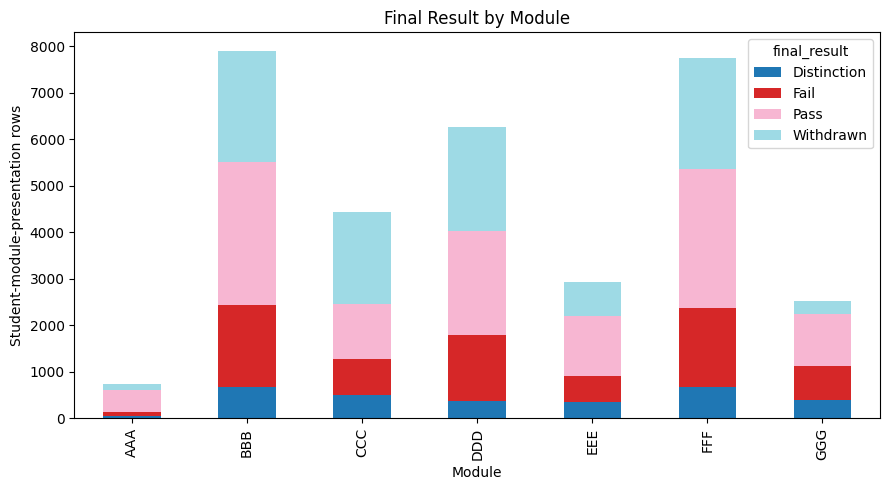

In [12]:
ax = result_by_module.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    colormap='tab20'
)

ax.set_title('Final Result by Module')
ax.set_xlabel('Module')
ax.set_ylabel('Student-module-presentation rows')
plt.tight_layout()
plt.show()